### Assignment 3

The data set I will use for visualization is from [City of Toronto’s Open Data Portal] (https://www.toronto.ca/city-government/data-research-maps/open-data/).The data set is about `Outbreaks in Toronto Healthcare Institutions` for year 2025 [Link to Dataset] https://open.toronto.ca/dataset/outbreaks-in-toronto-healthcare-institutions

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import seaborn as sns

df = pd.read_csv("ob_report_2025.csv")
df


,_id,Institution Name,Institution Address,Outbreak Setting,Type of Outbreak,Causative Agent-1,Causative Agent-2,Date Outbreak Began,Date Declared Over,Active
0,1,North York General Hospital - 4W,4001 Leslie St,Hospital-Acute Care,Respiratory,Influenza A (H3),NaN,2025-12-31,2026-01-07,N
1,2,"Rockcliffe Care Community - Ground, 1st & 2nd ...",3015 Lawrence Ave E,LTCH,Respiratory,Influenza A (H3),NaN,2025-12-31,2026-01-19,N
2,3,Belmont House Long Term Care - 4 West,55 Belmont St,LTCH,Respiratory,Influenza A (Not subtyped),NaN,2025-12-30,2026-01-09,N
3,4,Guildwood Retirement Residence,65 Livingston Rd,Retirement Home,Respiratory,Unable to identify,NaN,2025-12-30,2026-01-08,N
4,5,Kennedy Lodge - Main North & 3rd Fl North,1400 Kennedy Rd,LTCH,Respiratory,Parainfluenza,NaN,2025-12-30,2026-01-14,N
...,...,...,...,...,...,...,...,...,...,...
974,975,UHN - Toronto Western Hospital - 8A,399 Bathurst St,Hospital-Acute Care,Respiratory,Influenza A (Not subtyped),NaN,2025-01-02,2025-01-12,N
975,976,Unity Health Toronto - St. Joseph's Health Cen...,30 The Queensway,Hospital-Acute Care,Respiratory,Influenza A (Not subtyped),NaN,2025-01-02,2025-01-14,N
976,977,Runnymede Healthcare Centre - 3W,625 Runnymede Rd,Hospital-Chronic Care,Respiratory,Influenza A (Not subtyped),NaN,2025-01-01,2025-01-06,N
977,978,Runnymede Healthcare Centre - 4W,625 Runnymede Rd,Hospital-Chronic Care,Respiratory,Influenza A (Not subtyped),NaN,2025-01-01,2025-01-06,N


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   _id                  979 non-null    int64 
 1   Institution Name     979 non-null    object
 2   Institution Address  979 non-null    object
 3   Outbreak Setting     979 non-null    object
 4   Type of Outbreak     979 non-null    object
 5   Causative Agent-1    979 non-null    object
 6   Causative Agent-2    14 non-null     object
 7   Date Outbreak Began  979 non-null    object
 8   Date Declared Over   979 non-null    object
 9   Active               979 non-null    object
dtypes: int64(1), object(9)
memory usage: 76.6+ KB


From the info above, I noticed that `Causative Agent-2' has 14 non null values from 979 record. So I will not use this feaature in the visualiztion.

In [3]:
df['Institution Name'].value_counts() 

Institution Name
Unity Health Toronto - St. Joseph's Health Centre - 4M                  5
Better Living at Thompson House - 3rd Fl                                5
Unity Health Toronto - St. Joseph's Health Centre - 6G                  5
Weston Gardens Retirement Residence                                     4
Rockcliffe Care Community - 2nd Fl                                      4
                                                                       ..
Tony Stacey Centre for Veterans Care                                    1
Chartwell Grenadier Retirement Residence - 2nd & 4th Fl - A Building    1
Kipling Acres - 1 South (Humber Unit)                                   1
Leaside                                                                 1
The Hospital for Sick Children - 5B                                     1
Name: count, Length: 805, dtype: int64

There are 805 unique Institution names, this is large number to visualize. So I decided to look for ameaningful groupings to use in the visualizations.
<br>The first grouping is about the `Type of Outbreak` as shown in the cell below.

In [4]:
df['Type of Outbreak'].value_counts()

Type of Outbreak
Respiratory    878
Enteric         97
Other            4
Name: count, dtype: int64

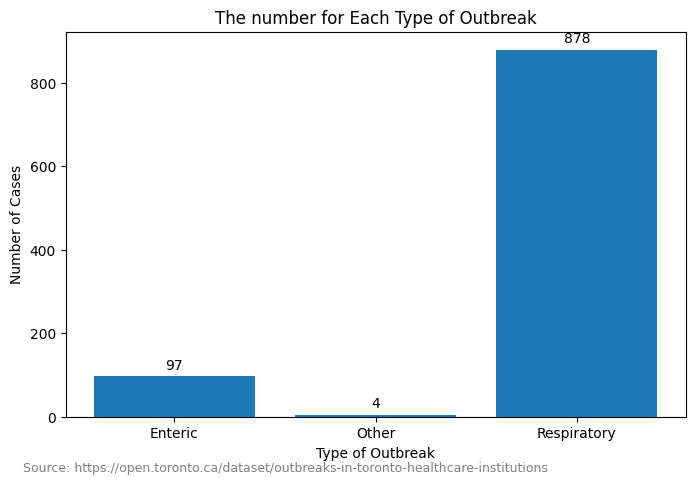

In [5]:
group_sizes = df.groupby('Type of Outbreak').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(group_sizes['Type of Outbreak'],group_sizes['Count'])
ax.set_title('The number for Each Type of Outbreak')
ax.set_ylabel('Number of Cases')
ax.set_xlabel('Type of Outbreak')
bars = ax.containers[0] 
ax.bar_label(bars, fmt='{:,.0f}', padding=3) 
# Add source text at the bottom
plt.figtext(0.4, 0.0, "Source: https://open.toronto.ca/dataset/outbreaks-in-toronto-healthcare-institutions", ha="center", fontsize=9, color="gray")
plt.show()

The bar graph above shows that Respiratory outbreaks are the largest among the types of outbreaks.
<br>So I decided to look at the `Causative Agent-1` feature for the Respiratory records.
<br> The bar graph below showing that `Covid-19' is the largest type, then followed by `Influenza A (Not Subtyped)`.

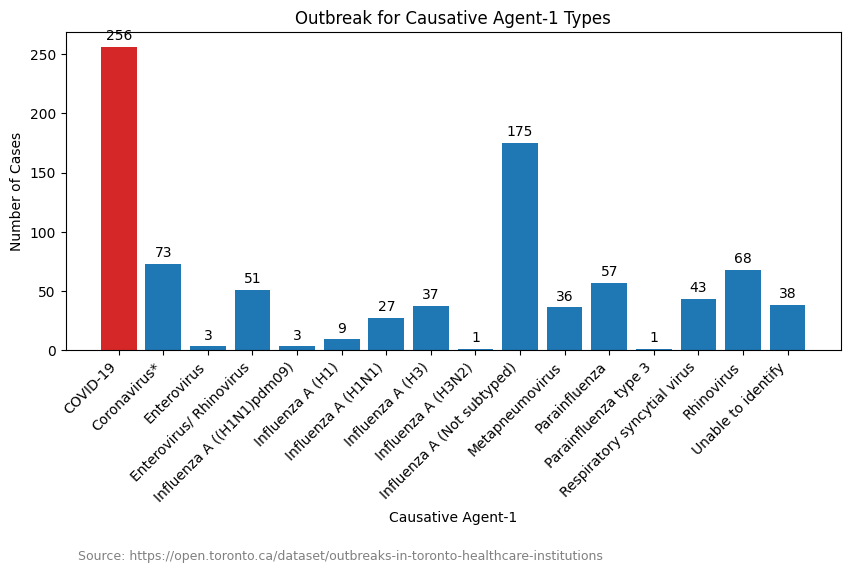

In [6]:
groups_causative_agent_1 = df.groupby(['Type of Outbreak', 'Causative Agent-1']).size().reset_index(name='Count')

filtered_df = groups_causative_agent_1[groups_causative_agent_1['Type of Outbreak'].isin(['Respiratory'])]
fig, ax = plt.subplots(figsize=(10, 6))

# Find max value
values = filtered_df['Count']
max_value = max(values)

# Assign colors (highlight max)
colors = ['tab:red' if v == max_value else 'tab:blue' for v in values]

ax.bar(filtered_df['Causative Agent-1'],filtered_df['Count'], color = colors)
ax.set_title('Outbreak for Causative Agent-1 Types')
ax.set_ylabel('Number of Cases')
ax.set_xlabel('Causative Agent-1')
bars = ax.containers[0] 
ax.bar_label(bars, fmt='{:,.0f}', padding=3) 
plt.xticks(rotation=45, ha='right')
# Make space at the bottom
plt.subplots_adjust(bottom=0.35)  # Increase bottom margin
# Add source text at the bottom
plt.figtext(0.4, 0.0, "Source: https://open.toronto.ca/dataset/outbreaks-in-toronto-healthcare-institutions", ha="center", fontsize=9, color="gray")
plt.show()

To investigate more the Respiratory outbreaks, I decideed to at `Outbreak Setting` as well. The graph shows that `LCTH` is the largest `setting` in the Respiratory cases.

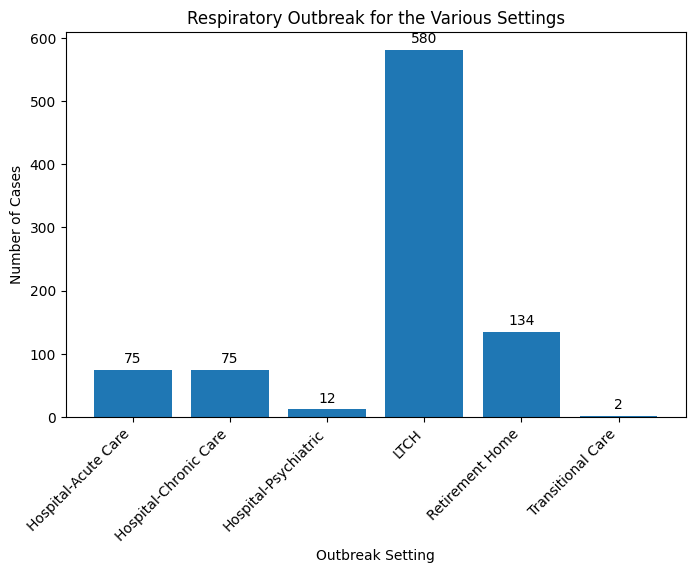

In [7]:
groups_outbreak_setting = df.groupby(['Type of Outbreak', 'Outbreak Setting']).size().reset_index(name='Count')

filtered_df = groups_outbreak_setting[groups_outbreak_setting['Type of Outbreak'].isin(['Respiratory'])]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(filtered_df['Outbreak Setting'],filtered_df['Count'])
ax.set_title('Respiratory Outbreak for the Various Settings')
ax.set_ylabel('Number of Cases')
ax.set_xlabel('Outbreak Setting')
bars = ax.containers[0] 
ax.bar_label(bars, fmt='{:,.0f}', padding=3) 
plt.xticks(rotation=45, ha='right')
plt.show()

Conclusion:
<br>This investigation with the help of visualization clearly indicates that Respiratoty is the largest outbreaks in `Toronto Healthcare Institutions`. Covid-19 is the largest type, and LTCH is the setting where most of the cases are found. This will give the us a very helpful inforation where to focus the attention and have more attention accordingly.